In [40]:
# import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import shap
import lightgbm as lgb

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    log_loss, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
shap.initjs()

In [41]:
# Load all CSV files in the specified folder into a single DataFrame
import glob, os

CSV_FOLDER = './MachineLearningCVE'        
csv_files = glob.glob(os.path.join(CSV_FOLDER, '*.csv'))

if csv_files:
    dfs = []
    for f in csv_files:
        print(f'Loading: {f}')
        tmp = pd.read_csv(f, low_memory=False)
        dfs.append(tmp)
    df = pd.concat(dfs, ignore_index=True)
    print(f'\nTotal rows loaded: {len(df):,}')
else:
    raise FileNotFoundError('No CSV files found. Update CSV_FOLDER path.')

df.head()

Loading: ./MachineLearningCVE\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Monday-WorkingHours.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Tuesday-WorkingHours.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Wednesday-workingHours.pcap_ISCX.csv

Total rows loaded: 2,830,743


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [42]:
# Display basic info about the DataFrame
print('DataFrame Info:')
print(df.info())
print('Shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max    

In [43]:
# Standardise column names (strip spaces, common CICIDS quirk)
df.columns = df.columns.str.strip()

# Identify label column (CICIDS2017 uses ' Label' or 'Label')
LABEL_COL = 'Label'
if LABEL_COL not in df.columns:
    LABEL_COL = [c for c in df.columns if 'label' in c.lower()][0]
print(f'Label column: "{LABEL_COL}"')

print('\nClass distribution:')
print(df[LABEL_COL].value_counts())

Label column: "Label"

Class distribution:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


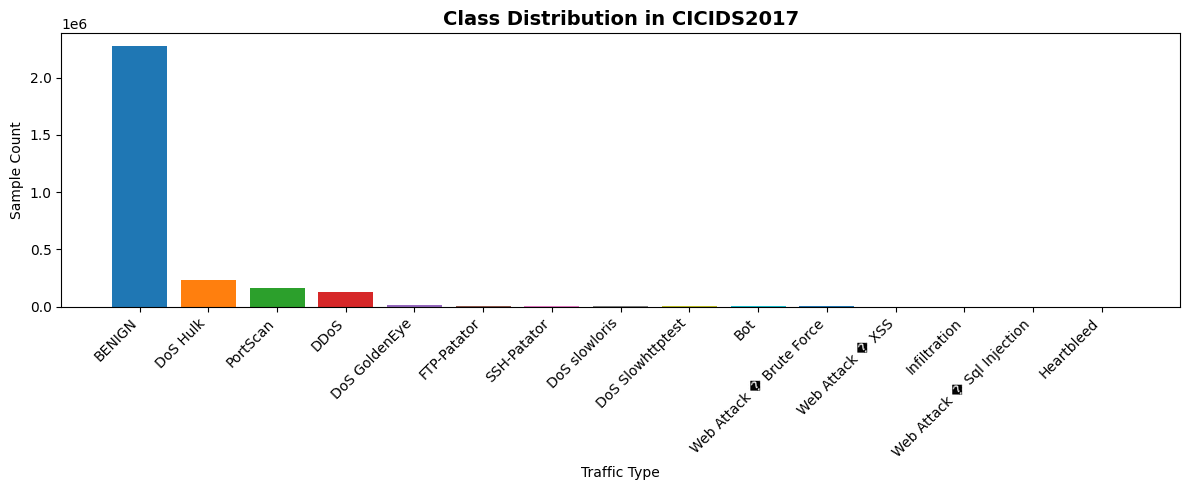

In [44]:
# Visualise class distribution
fig, ax = plt.subplots(figsize=(12, 5))
counts = df[LABEL_COL].value_counts()
ax.bar(counts.index, counts.values, color=plt.cm.tab10.colors[:len(counts)])
ax.set_title('Class Distribution in CICIDS2017', fontsize=14, fontweight='bold')
ax.set_xlabel('Traffic Type')
ax.set_ylabel('Sample Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [45]:
# Drop non-numeric / identifier columns
drop_cols = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp',
             'Src IP', 'Dst IP', 'src_ip', 'dst_ip']
drop_cols = [c for c in drop_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)

# Replace inf / -inf with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop columns with > 50% missing
thresh = len(df) * 0.5
df.dropna(axis=1, thresh=thresh, inplace=True)

# DROP rows with ANY NaN (simpler baseline approach)
print(f'Shape before dropping NaNs: {df.shape}')
df.dropna(inplace=True)
print(f'Shape after dropping NaNs : {df.shape}')

# KEEP DUPLICATES (don't remove them - baseline approach)
print(f'Missing values: {df.isnull().sum().sum()}')

Shape before dropping NaNs: (2830743, 79)
Shape after dropping NaNs : (2827876, 79)
Missing values: 0


In [46]:
# Encode labels
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df[LABEL_COL].astype(str))

class_names = le.classes_
n_classes   = len(class_names)
print(f'\nNumber of classes: {n_classes}')
for i, name in enumerate(class_names):
    print(f'  {i}: {name}')


Number of classes: 15
  0: BENIGN
  1: Bot
  2: DDoS
  3: DoS GoldenEye
  4: DoS Hulk
  5: DoS Slowhttptest
  6: DoS slowloris
  7: FTP-Patator
  8: Heartbleed
  9: Infiltration
  10: PortScan
  11: SSH-Patator
  12: Web Attack � Brute Force
  13: Web Attack � Sql Injection
  14: Web Attack � XSS


In [47]:
# Features / target split
X = df.drop(columns=[LABEL_COL, 'label_enc'])
X = X.select_dtypes(include=[np.number])   # keep only numeric
y = df['label_enc']

print(f'Features: {X.shape[1]}  |  Samples: {X.shape[0]}')

Features: 78  |  Samples: 2827876


In [48]:
# Train / Test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (2262300, 78)  |  Test: (565576, 78)


In [58]:
# import necessary libraries for Bagging Decision Tree
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Base estimator: Decision Tree
base_dt = DecisionTreeClassifier(
    criterion      = 'gini',
    max_depth      = 7,
    min_samples_split = 100,
    min_samples_leaf  = 50,
    random_state   = 42,
)

# Bagging wrapper
model = BaggingClassifier(
    estimator      = base_dt,
    n_estimators   = 8,         # number of trees in the bag
    max_samples    = 0.5,       # 50% of training data per bag
    max_features   = 0.5,       # 50% of features per bag
    bootstrap      = True,
    bootstrap_features = False,
    n_jobs         = -1,
    random_state   = 42,
    verbose        = 0,
)

# Compute sample weights to handle class imbalance
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

print('Training Bagging Decision Tree...')
model.fit(X_train, y_train, sample_weight=sample_weights)
print('Training complete.')

Training Bagging Decision Tree...
Training complete.


In [59]:


# Track val log loss as we add more estimators (staged evaluation)
staged_logloss = []
estimator_counts = list(range(1, model.n_estimators + 1))

# Accumulate predictions across estimators manually
proba_accum = np.zeros((len(X_test), n_classes))

for i, est in enumerate(model.estimators_):
    # Each base estimator was trained on a bootstrap sample of features
    features_idx = model.estimators_features_[i]
    proba_i      = est.predict_proba(X_test.iloc[:, features_idx])

    # Align class columns (base DT may not see all classes)
    full_proba = np.zeros((len(X_test), n_classes))
    for j, cls in enumerate(est.classes_):
        full_proba[:, cls] = proba_i[:, j]

    proba_accum += full_proba
    avg_proba    = proba_accum / (i + 1)

    # Clip to avoid log(0)
    avg_proba = np.clip(avg_proba, 1e-7, 1)
    avg_proba = avg_proba / avg_proba.sum(axis=1, keepdims=True)

    staged_logloss.append(log_loss(y_test, avg_proba))

best_ll_iter = int(np.argmin(staged_logloss)) + 1
best_ll_val  = staged_logloss[best_ll_iter - 1]

print(f'Best iteration : {best_ll_iter}')
print(f'Val Log Loss   : {best_ll_val:.6f}')

Best iteration : 6
Val Log Loss   : 0.659256


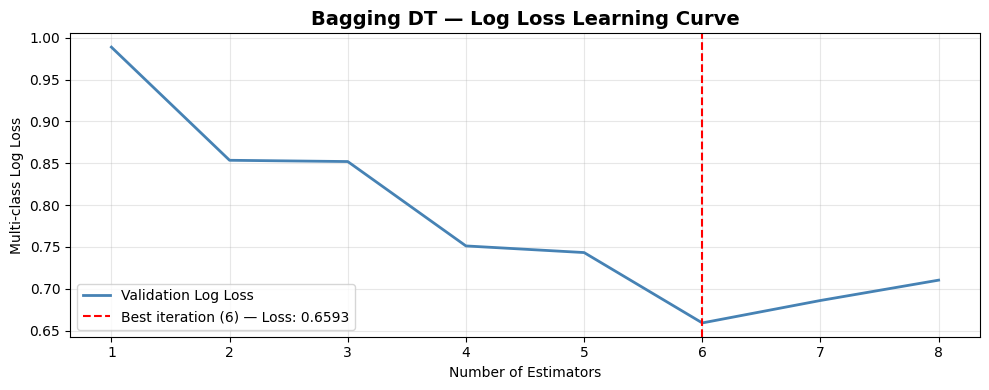

In [60]:
# Plot log loss learning curve
plt.figure(figsize=(10, 4))
plt.plot(estimator_counts, staged_logloss, linewidth=2, color='steelblue',
         label='Validation Log Loss')
plt.axvline(x=best_ll_iter, color='red', linestyle='--',
            label=f'Best iteration ({best_ll_iter}) — Loss: {best_ll_val:.4f}')
plt.title('Bagging DT — Log Loss Learning Curve', fontsize=14, fontweight='bold')
plt.xlabel('Number of Estimators')
plt.ylabel('Multi-class Log Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
# Final evaluation on test set using all estimators
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)   

# Accuracy
acc  = accuracy_score(y_test, y_pred)

# Precision / Recall / F1 (weighted) 
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score   (y_test, y_pred, average='weighted', zero_division=0)
f1   = f1_score       (y_test, y_pred, average='weighted', zero_division=0)

# Log Loss
ll   = log_loss(y_test, y_pred_prob)

# AUC-ROC (One-vs-Rest, weighted)
auc  = roc_auc_score(y_test, y_pred_prob, multi_class='ovr', average='weighted')


print('       EVALUATION METRICS (Test Set)')

print(f'  Accuracy          : {acc:.4f}')
print(f'  Precision (w-avg) : {prec:.4f}')
print(f'  Recall    (w-avg) : {rec:.4f}')
print(f'  F1-Score  (w-avg) : {f1:.4f}')
print(f'  AUC-ROC   (w-avg) : {auc:.4f}')
print(f'  Log Loss          : {ll:.4f}')


       EVALUATION METRICS (Test Set)
  Accuracy          : 0.8993
  Precision (w-avg) : 0.9680
  Recall    (w-avg) : 0.8993
  F1-Score  (w-avg) : 0.9280
  AUC-ROC   (w-avg) : 0.9863
  Log Loss          : 0.7104


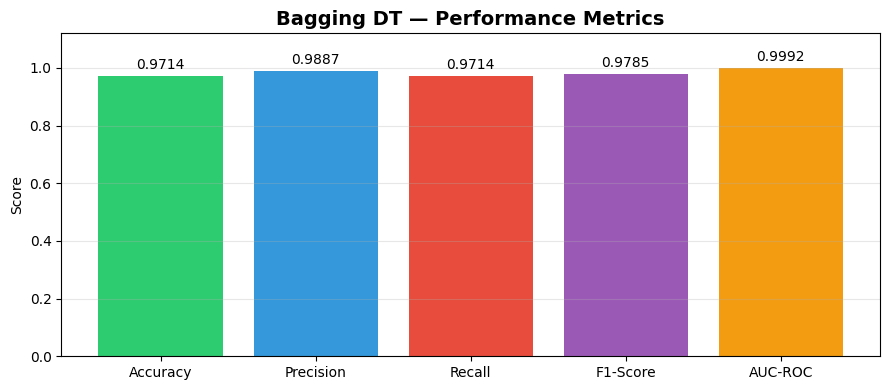

Log Loss: 0.1422  (lower is better, not plotted above)


In [ ]:
# Metrics bar chart
metrics = {
    'Accuracy' : acc,
    'Precision': prec,
    'Recall'   : rec,
    'F1-Score' : f1,
    'AUC-ROC'  : auc,
}

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(metrics.keys(), metrics.values(),
              color=['#2ecc71','#3498db','#e74c3c','#9b59b6','#f39c12'])
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_title('Bagging DT — Performance Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Log Loss: {ll:.4f}  (lower is better, not plotted above)')

In [ ]:
print(classification_report(
    y_test, y_pred,
    target_names=class_names,
    zero_division=0
))

                            precision    recall  f1-score   support

                    BENIGN       1.00      0.97      0.98    454265
                       Bot       0.10      1.00      0.17       391
                      DDoS       1.00      1.00      1.00     25605
             DoS GoldenEye       0.56      0.96      0.71      2059
                  DoS Hulk       0.94      0.99      0.97     46025
          DoS Slowhttptest       0.37      0.98      0.54      1100
             DoS slowloris       0.25      0.97      0.40      1159
               FTP-Patator       1.00      1.00      1.00      1587
                Heartbleed       0.22      1.00      0.36         2
              Infiltration       0.54      1.00      0.70         7
                  PortScan       0.99      1.00      0.99     31761
               SSH-Patator       1.00      1.00      1.00      1180
  Web Attack � Brute Force       0.20      0.47      0.28       301
Web Attack � Sql Injection       0.01      1.00

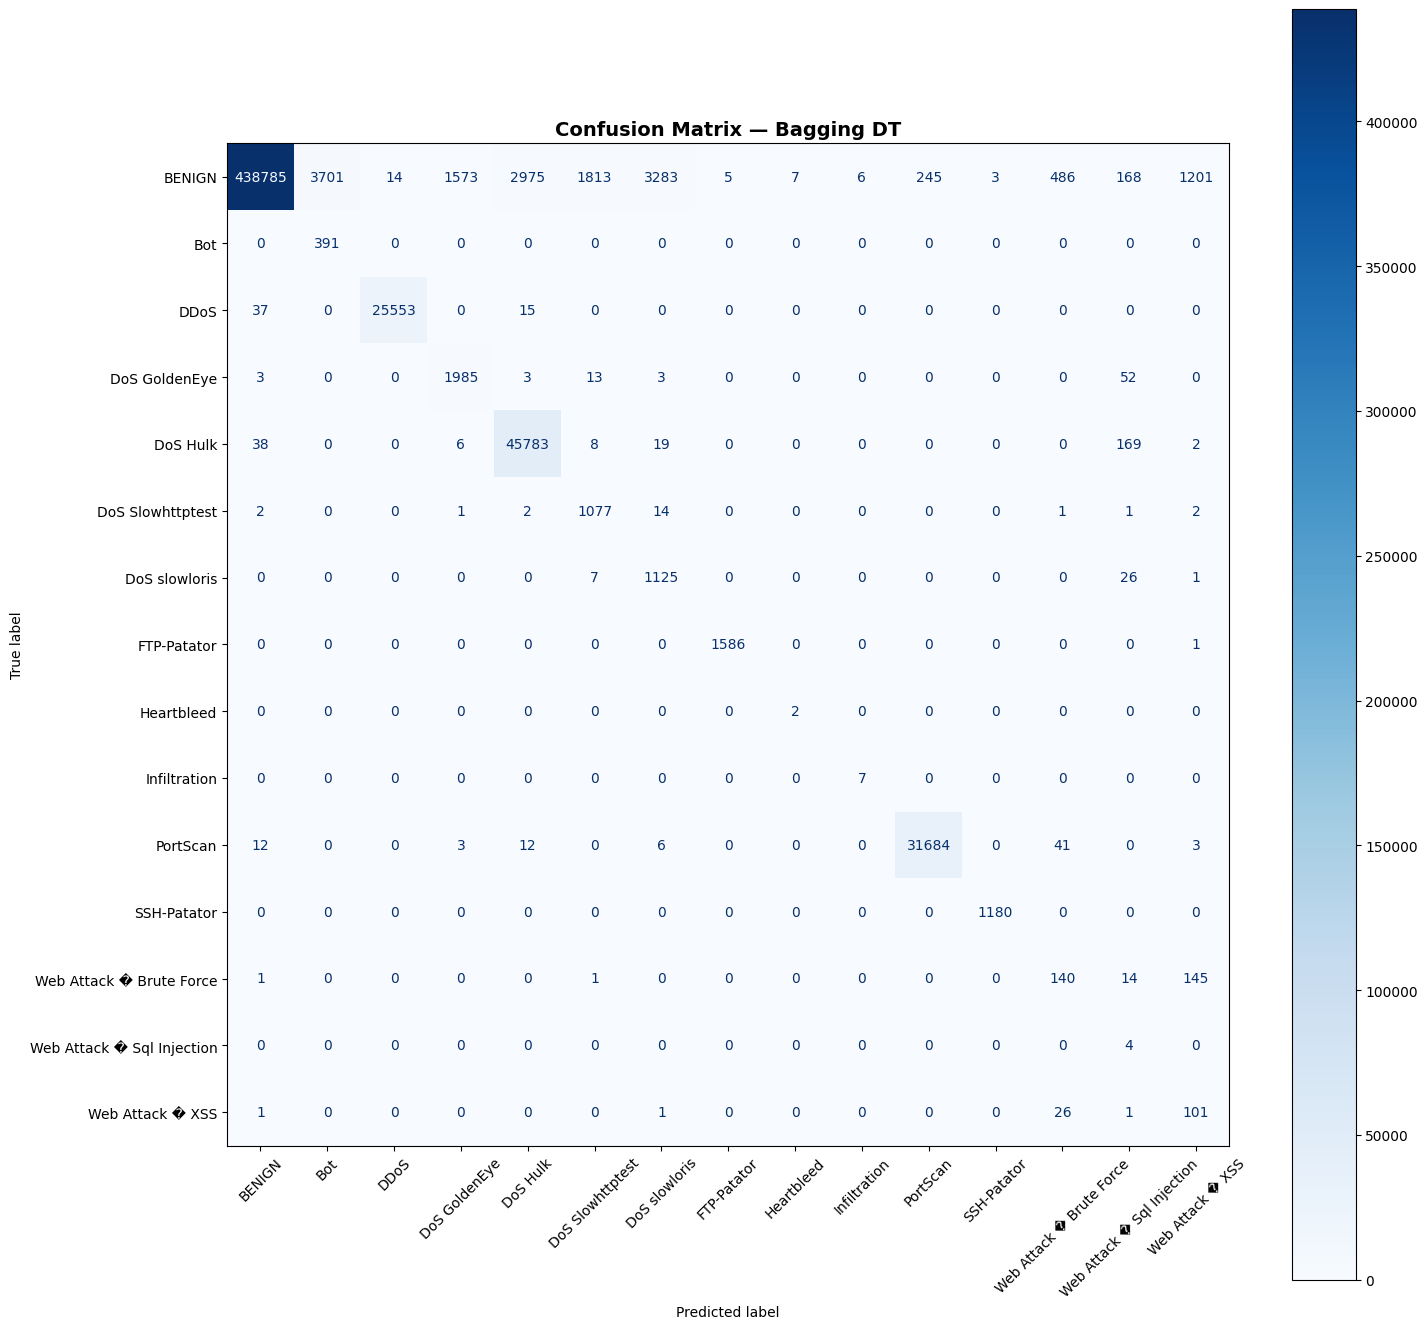

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(max(8, n_classes), max(6, n_classes - 1)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
ax.set_title('Confusion Matrix — Bagging DT', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

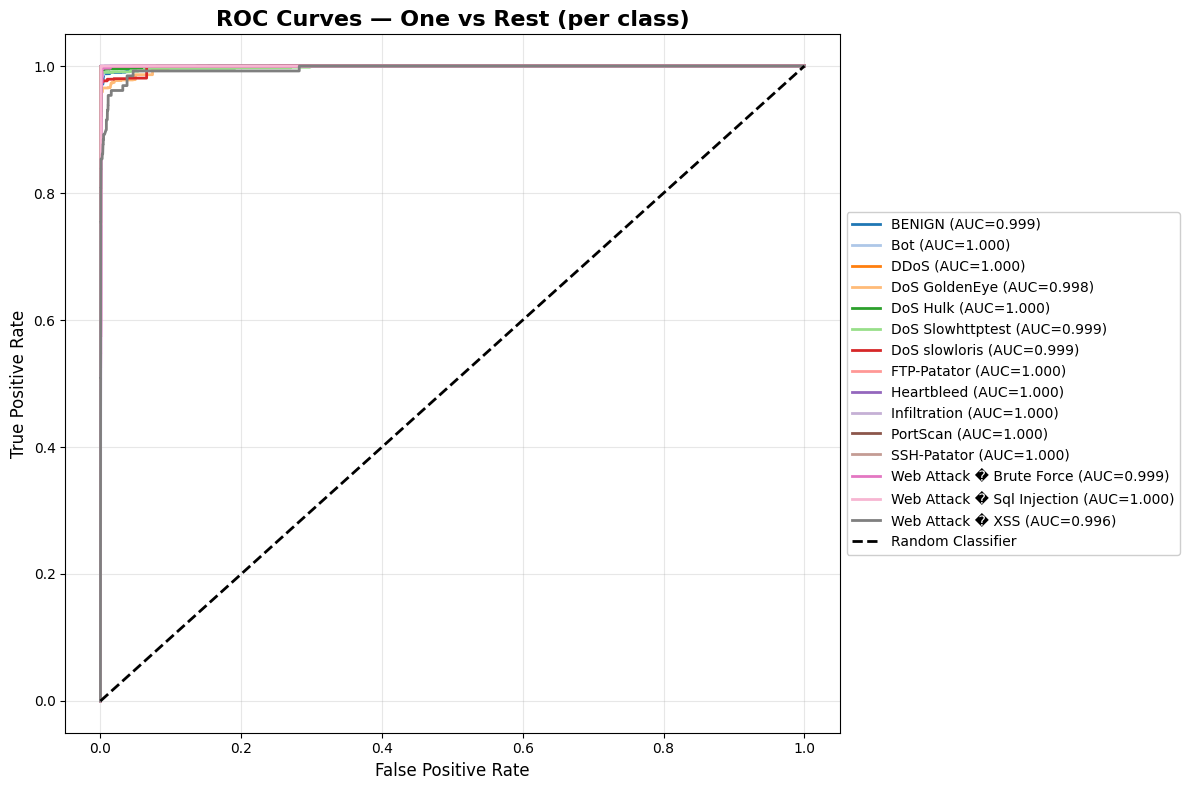

In [ ]:
# ROC Curves (One-vs-Rest)
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

fig, ax = plt.subplots(figsize=(12, 8))
colors  = plt.cm.tab20.colors

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc_i = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2.0, color=colors[i % 20],
            label=f'{class_names[i]} (AUC={roc_auc_i:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
ax.set_title('ROC Curves — One vs Rest (per class)', fontsize=16, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10, framealpha=0.95)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()